В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

medical_df = pd.read_csv('medical-charges.csv')
non_smoker_df = medical_df[medical_df.smoker == 'no']

X = non_smoker_df['age']
y = non_smoker_df['charges']
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]

In [2]:
# метод найменших квадратів
def normal_equations(X,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

# RSME    
def RMSE(pred, y):
    return np.sqrt(sum((pred - y) ** 2)/len(y))

# Full-Batch градієнтний спуск
def full_batch_gradient_descent(X, y, lr=0.0001, epochs=100):
    m, b = 0.0, 0.0
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X)
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

In [3]:
# метод найменших квадратів
MNK_coefs = normal_equations(X_with_intercept, y)

predictions_mnk = np.dot(X_with_intercept, MNK_coefs)
RMSE_mnk = RMSE(predictions_mnk, y)

print(f'Коефіцієнти моделі: m = {MNK_coefs[1]}, b = {MNK_coefs[0]}')
print(f'RMSE = {RMSE_mnk}')

Коефіцієнти моделі: m = 267.24891283119973, b = -2091.4205565650796
RMSE = 4662.505766636393


Коментар: результат майже співпадає із тим, що я малювала на графіку в попередньому ДЗ (m = 260, b = -2000, RMSE = 4667.66)

In [4]:
# метод градієнтного спуску, ітерація 0
m, b, errors = full_batch_gradient_descent(X, y, lr=0.1, epochs=100)

predictions_fbgd_0 = m * X + b
RMSE_0 = RMSE(predictions_fbgd_0, y)

print(f'Коефіцієнти моделі: m = {m}, b = {b}')
print(f'RMSE = {RMSE_0}')

Коефіцієнти моделі: m = -4.277831608428094e+256, b = -9.631788946042329e+254
RMSE = inf


Коментар:
З параметром epochs=1000 отримала помилку runtime overflow, тому зменшила до значення 100, коефіцієнти вийшли погані, а RSME = inf, що звісно ж є дуже погано

In [5]:
# метод градієнтного спуску, ітерація 1
m, b, errors = full_batch_gradient_descent(X, y, lr=1e-3, epochs=100)

predictions_fbgd_1 = m * X + b
RMSE_1 = RMSE(predictions_fbgd_1, y)

print(f'Коефіцієнти моделі: m = {m}, b = {b}')
print(f'RMSE = {RMSE_1}')

Коефіцієнти моделі: m = -1.3967624262082842e+42, b = -3.1448925830775484e+40
RMSE = 5.844970923943416e+43


Коментар:
Зменшила lr= до 0.001, при epochs=1000 все ще отримуємо runtime overflow, коефіцієнти і RSME - все ще дуже великі

In [6]:
# метод градієнтного спуску, ітерація 2
m, b, errors = full_batch_gradient_descent(X, y, lr=1e-5, epochs=10000)

predictions_fbgd_2 = m * X + b
RMSE_2 = RMSE(predictions_fbgd_2, y)

print(f'Коефіцієнти моделі: m = {m}, b = {b}')
print(f'RMSE = {RMSE_2}')

Коефіцієнти моделі: m = 221.10457373276387, b = -41.980795673907885
RMSE = 4713.250606105698


Коментар:
При lr=1е-5 epochs=1000 результат вже виглядає по-людськи, але збільшенням кількості ітерацій чи зменшенням lr не вдається суттєво покращити його. RMSE вже дуже близька до методу найменших квадратів

In [7]:
# метод градієнтного спуску, ітерація 3
X_scaled = (X - X.mean())/X.std()
m, b, errors = full_batch_gradient_descent(X_scaled, y, lr=0.1, epochs=100)

b = b - m * X.mean() / X.std()
m = m / X.std()

predictions_fbgd_3 = m * X + b
RMSE_3 = RMSE(predictions_fbgd_3, y)

print(f'Коефіцієнти моделі: m = {m}, b = {b}')
print(f'RMSE = {RMSE_3}')

Коефіцієнти моделі: m = 267.248912775466, b = -2091.4205560880873
RMSE = 4662.505766636395


Коментар: спробувала заскейлити нашу залежну змінну і вдалось досягнути ідеального результату з початковими параметрами lr=0.1 epochs=100

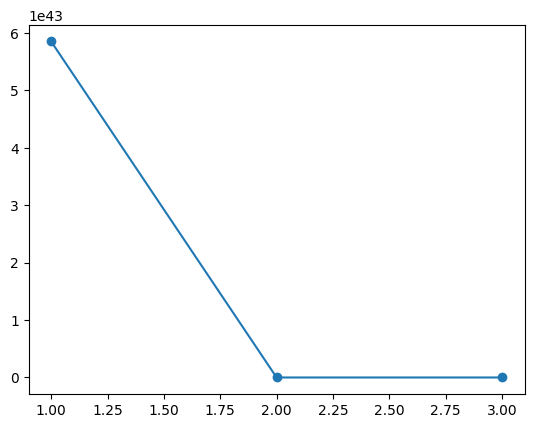

In [8]:
# візуалізація помилки залежно від ітерації
errors = [RMSE_0, RMSE_1, RMSE_2, RMSE_3]
plt.plot(errors, marker='o')

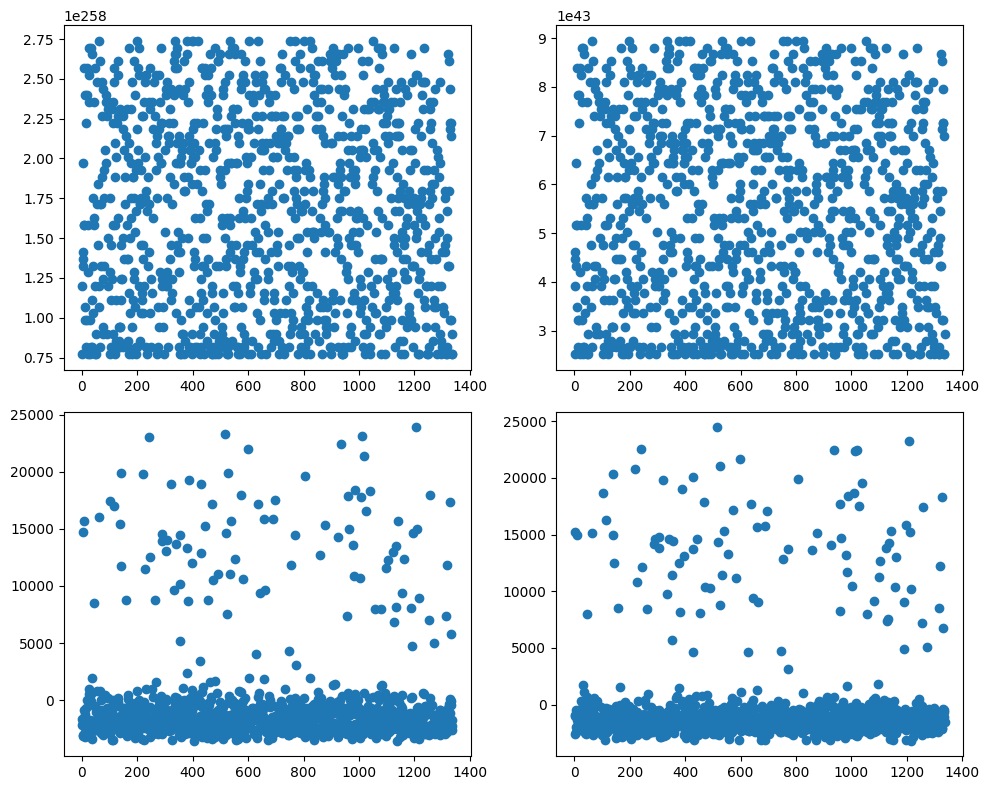

In [9]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))
ax1.plot(y - predictions_fbgd_0, 'o')
ax2.plot(y - predictions_fbgd_1, 'o')
ax3.plot(y - predictions_fbgd_2, 'o')
ax4.plot(y - predictions_fbgd_3, 'o')
plt.tight_layout()
plt.show()

Коментар: зі збільшенням точності залишки перестають бути гомоскедастичними ( я так розумію, це через викиди )

In [10]:
# Модель лінійної регресії засобами Scikit-learn
lin_reg = LinearRegression()
lin_reg.fit(X_with_intercept, y)

predictions_sklearn = lin_reg.predict(X_with_intercept)
RMSE_sklearn = RMSE(predictions_sklearn, y)

print(f'Коефіцієнти моделі: m = {lin_reg.coef_[1]}, b = {lin_reg.intercept_}')
print(f'RMSE = {RMSE_sklearn}')

Коефіцієнти моделі: m = 267.2489128311982, b = -2091.420556565028
RMSE = 4662.505766636393


Коментар: результат такий же, як і при МНК та ітерації 3 методу градієнтного спуску

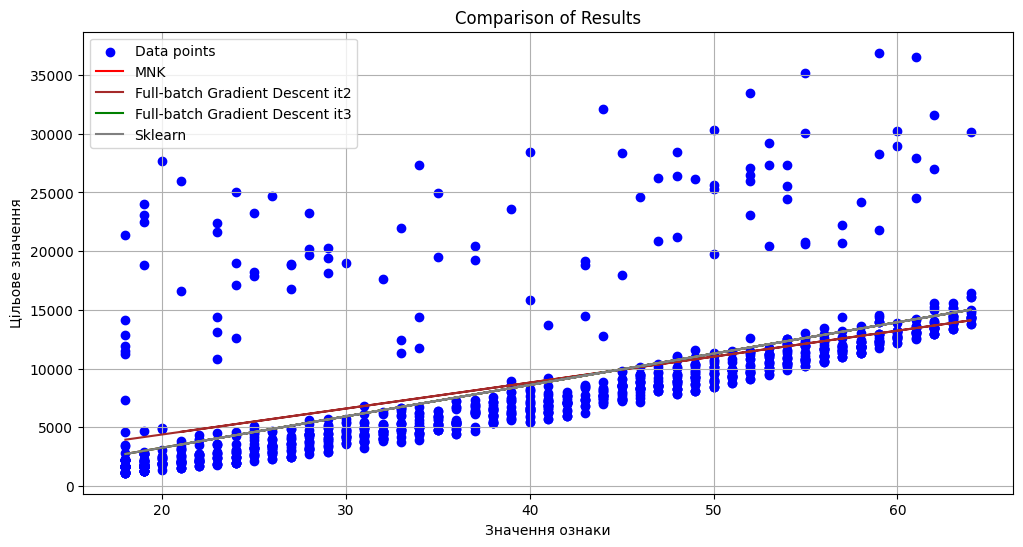

In [11]:
#візуалізація
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_mnk, color='red', label='MNK')
plt.plot(X, predictions_fbgd_2, color='brown', label='Full-batch Gradient Descent it2')
plt.plot(X, predictions_fbgd_3, color='green', label='Full-batch Gradient Descent it3')
plt.plot(X, predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Results')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

Коментар: всі лінії накладаються одна на одну, для різноманіття додала ще передостанню ітерацію методу градієнтного спуску. Точність трьох методів співпадає в даному випадку і близька до моїх припущень із попереднього ДЗ

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

Коефіцієнти моделі: m = 305.2376021098288, b = 20294.128126915966
RMSE = 10711.00334810241


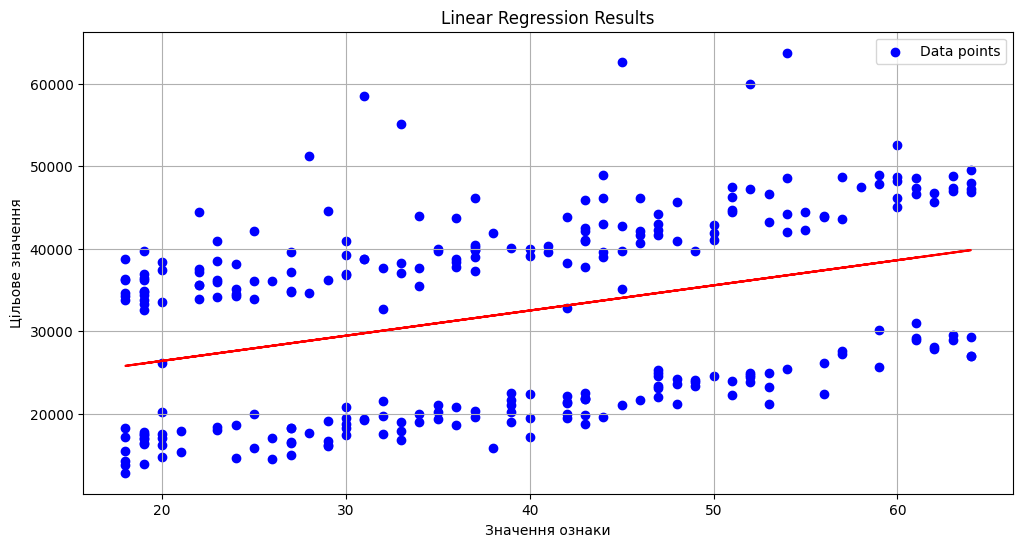

In [12]:
smoker_df = medical_df[medical_df.smoker == 'yes']

X = smoker_df['age']
y = smoker_df['charges']
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]

lin_reg = LinearRegression()
lin_reg.fit(X_with_intercept, y)

predictions_sklearn = lin_reg.predict(X_with_intercept)
RMSE_sklearn = RMSE(predictions_sklearn, y)

print(f'Коефіцієнти моделі: m = {lin_reg.coef_[1]}, b = {lin_reg.intercept_}')
print(f'RMSE = {RMSE_sklearn}')

plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_sklearn, color='red')
plt.title('Linear Regression Results')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

Коментар: в даному випадку модель максимально можливо точна - лінія проходить посередині двох кластерів даних, але похибка дуже велика, тому що до двох кластерів однаково далеко.

Я би її не використовувала для роботи. Краще розділити дані на два кластери і побудувати лінійну регресію для кожного із них. Висновок підтверджується візуалізацією залишків, які не є гомоскедастичними і не мають нормального розподілу (але ймовірно, що це сума двох розподілів, наближених до нормального + викиди)

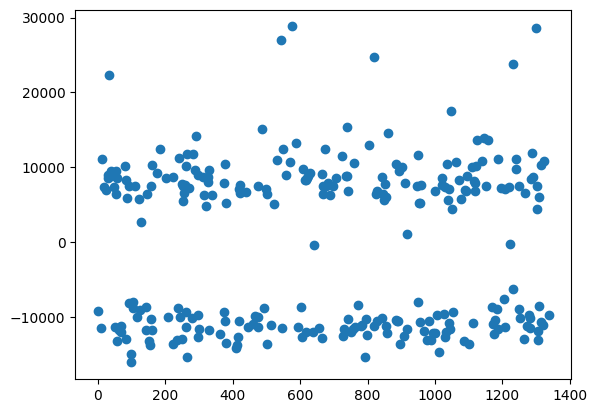

In [13]:
plt.plot(y - predictions_sklearn, 'o')

(array([ 5., 11., 35., 42., 23.,  6.,  1.,  0.,  0.,  0.,  2.,  1.,  1.,
         3., 15., 46., 32., 22., 10.,  7.,  4.,  1.,  1.,  0.,  0.,  1.,
         1.,  1.,  1.,  2.]),
 array([-16072.45800709, -14576.22338393, -13079.98876077, -11583.75413761,
        -10087.51951445,  -8591.28489129,  -7095.05026814,  -5598.81564498,
         -4102.58102182,  -2606.34639866,  -1110.1117755 ,    386.12284766,
          1882.35747082,   3378.59209398,   4874.82671714,   6371.06134029,
          7867.29596345,   9363.53058661,  10859.76520977,  12355.99983293,
         13852.23445609,  15348.46907925,  16844.70370241,  18340.93832557,
         19837.17294873,  21333.40757188,  22829.64219504,  24325.8768182 ,
         25822.11144136,  27318.34606452,  28814.58068768]),
 <BarContainer object of 30 artists>)

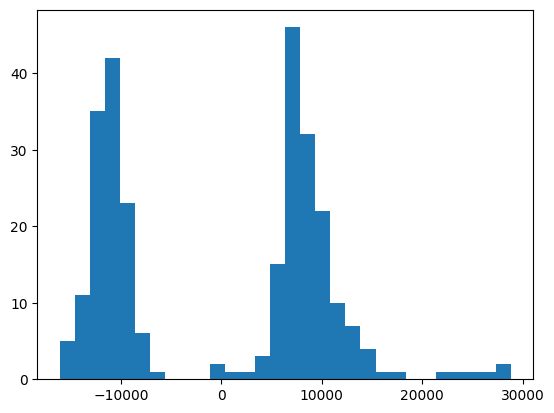

In [14]:
plt.hist(y - predictions_sklearn, bins = 30)